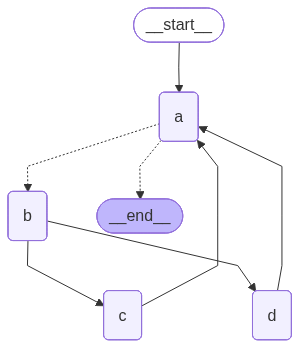

In [3]:

import operator
from typing import Annotated,Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f'Node A sees {state["aggregate"]}')
    return {"aggregate":["A"]}


def b(state:State):
    print(f'Node B sees {state["aggregate"]}')
    return {"aggregate":["B"]}


def c(state:State):
    print(f'Node C sees {state["aggregate"]}')
    return {"aggregate":["C"]}

def d(state:State):
    print(f'Node D sees {state["aggregate"]}')
    return {"aggregate":["D"]}

# Define nodes
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

# Define edges
def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","c")
builder.add_edge("b","d")
builder.add_edge(["c","d"],"a")

graph = builder.compile()

from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
result = graph.invoke({"aggregate":[]})

Node A sees []
Node B sees ['A']
Node C sees ['A', 'B']
Node D sees ['A', 'B']
Node A sees ['A', 'B', 'C', 'D']
Node B sees ['A', 'B', 'C', 'D', 'A']
Node C sees ['A', 'B', 'C', 'D', 'A', 'B']
Node D sees ['A', 'B', 'C', 'D', 'A', 'B']
Node A sees ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']
